# Atari Games - Space Invaders

The mission is to build an AI that "plays" Atari video games. I need to build 3 diffeent models that solve three different Atari games. This notebook is for the first game called Cart Pole. The goal is to train a model that plays it by balancing a pole on a cart. The subject asks for using reinforcement learning and Deep Q-networks.

## Table of contents:
* [Imports](#imports)
* [Creating environment](#enviroment)
* [Setting up statistics](#monitoring)
* [Model training](#training)
* [Training evaluation](#training_evaluation)
* [Model evaluation](#model_evaluation)

## Imports <a class="anchor" id="imports"></a>

In [2]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import ale_py

from gymnasium.wrappers import RecordEpisodeStatistics, FrameStackObservation, TransformObservation
from stable_baselines3 import DQN
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.atari_wrappers import AtariWrapper
from stable_baselines3.common.vec_env import VecFrameStack, DummyVecEnv

In [3]:
SEED = 142
np.random.seed(SEED)
gym.register_envs(ale_py)
plt.rcParams["figure.figsize"] = (10, 5)
ENV_ID = "SpaceInvadersNoFrameskip-v4"

## Creating enviroment <a class="anchor" id="enviroment"></a>

In [4]:
def make_env(env_id: str, training=True):
    def _init():
        if training:
            env = gym.make(env_id)
        else: 
            env = gym.make(env_id, render_mode="human")
        env = RecordEpisodeStatistics(env)
        return env

    env = DummyVecEnv([_init])   
    env = VecFrameStack(env, n_stack=4)
    return env

train_env = make_env(ENV_ID)

A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]


## Setting up statistics <a class="anchor" id="monitoring"></a>

In [43]:
class EpisodicReturnCallback(BaseCallback):
    def __init__(self, verbose=0) -> None:
        super().__init__(verbose)
        self.episode_returns = []
        self.episode_lengths = []

    def _on_step(self) -> bool:
        for info in self.locals.get("infos", []):
            if "episode" in info: 
                ep = info["episode"]
                self.episode_returns.append(float(ep["r"]))
                self.episode_lengths.append(int(ep["l"]))
        return True

## Model training <a class="anchor" id="training"></a>

In [49]:
dqn_kwargs = {
    "buffer_size": 10000,
    "learning_rate": 1e-6,
    "batch_size": 32,
    "learning_starts": 500,
    "target_update_interval": 100,
    "train_freq": 4,
    "gradient_steps": 1,
    "gamma": 0.99
}

model = DQN("CnnPolicy", train_env, **dqn_kwargs)

In [50]:
# Train
TOTAL_TIMESTAMPS = 10_000
log_cb = EpisodicReturnCallback()
model.learn(total_timesteps=TOTAL_TIMESTAMPS, callback=log_cb)

## Training evaluation <a class="anchor" id="training_evaluation"></a>

In [51]:
# Plot learning curve with rolling mean
def plot_training(returns, window=20):
    returns = np.array(returns, dtype=float)
    plt.figure()
    plt.plot(returns, label="episode return")
    if len(returns) >= window:
        cumsum = np.cumsum(np.insert(returns, 0, 0))
        rolling = (cumsum[window:] - cumsum[:-window]) / window
        # Align the rolling curve to the right edge of the window for readability
        x = np.arange(window-1, len(returns))
        plt.plot(x, rolling, label=f"rolling mean ({window})")
    plt.title("DQN on Space Invaders-v4 - Episode Returns")
    plt.xlabel("Episode")
    plt.ylabel("Return")
    plt.legend()
    plt.show()

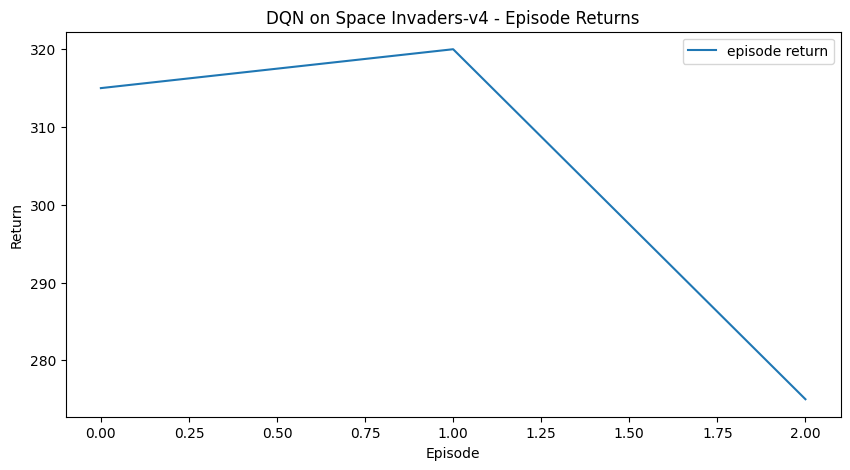

In [52]:
plot_training(log_cb.episode_returns, 10)

In [53]:
np.mean(log_cb.episode_returns)

np.float64(303.3333333333333)

1st round -> dqn_kwargs = {
    "buffer_size": 10000,
    "learning_rate": 1e-5,
    "batch_size": 32,
    "learning_starts": 500,
    "target_update_interval": 100,
    "train_freq": 4,
    "gradient_steps": 1,
    "gamma": 0.99
}
with 10_000 timestamps - returns ~120 <br>

2nd round -> dqn_kwargs = {
    "buffer_size": 10000,
    "learning_rate": 1e-4,
    "batch_size": 32,
    "learning_starts": 500,
    "target_update_interval": 100,
    "train_freq": 4,
    "gradient_steps": 1,
    "gamma": 0.99
}
with 10_000 timestamps - returns ~86 <br>

3rd round -> dqn_kwargs = {
    "buffer_size": 10000,
    "learning_rate": 1e-6,
    "batch_size": 32,
    "learning_starts": 500,
    "target_update_interval": 100,
    "train_freq": 4,
    "gradient_steps": 1,
    "gamma": 0.99
}
with 10_000 timestamps - returns ~303 <br>

## Model Evaluation <a class="anchor" id="model_evaluation"></a>

In [11]:
def evaluate_greedy(model, n_episodes=5):
    # render_mode="human" will show the SpaceInvaders window
    test_env = make_env(ENV_ID, training=False)

    scores = []
    try:
        for ep in range(n_episodes):
            # Reset with a changing seed for variety across episodes
            obs, _ = test_env.reset(seed=SEED + 100 + ep)
            terminated = False
            truncated = False
            total_r = 0.0

            while not (terminated or truncated):
                action, _ = model.predict(obs, deterministic=True)
                obs, reward, terminated, truncated, _ = test_env.step(action)
                total_r += float(reward)

            print(f"Episode {ep + 1}: return={total_r:.1f}")
            scores.append(total_r)
    finally:
        test_env.close()

    if len(scores) > 0:
        print(f"Average return score: {np.mean(scores)} ± {np.std(scores):.1f}")

    return scores

# Run a quick check
_ = evaluate_greedy(model, 1)

TypeError: VecFrameStack.reset() got an unexpected keyword argument 'seed'

In [32]:
model.save("space_invaders_model")